# Lab 1

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
# import random
# from PIL import Image
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Found 3200 files belonging to 2 classes.
Found 600 files belonging to 2 classes.
Found 600 files belonging to 2 classes.


Model: "cats_dogs_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 94s 880ms/step - accuracy: 0.8971 - loss: 0.2850 - val_accuracy: 0.9750 - val_loss: 0.0929
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 85s 847ms/step - accuracy: 0.9744 - loss: 0.0815 - val_accuracy: 0.9800 - val_loss: 0.0686
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 85s 853ms/step - accuracy: 0.9781 - loss: 0.0662 - val_accuracy: 0.9800 - val_loss: 0.0594
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 833ms/step - accuracy: 0.9791 - loss: 0.0544 - val_accuracy: 0.9833 - val_loss: 0.0561
Epoch 5/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 833ms/step - accuracy: 0.9823 - loss: 0.0509 - val_accuracy: 0.9850 - val_loss: 0.0525
Epoch 6/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 827ms/step - accuracy: 0.9809 - loss: 0.0493 - val_accuracy: 0.9850 - val_loss: 0.0496
Epoch 7/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 826ms/step - accuracy: 0.9855 - loss: 0.0393 - val_accuracy: 0.9850 - val_loss: 0.0516
Epoch 8/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 829ms/step - accuracy: 0.9856 - loss: 0.0394 - 

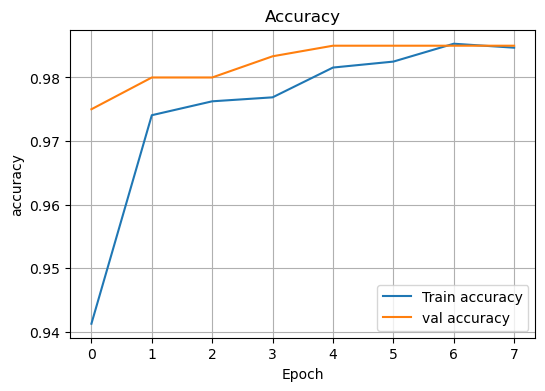

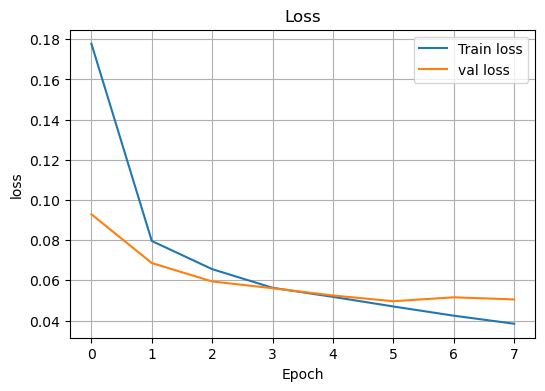

In [ ]:
SEED = 42
tf.random.set_seed(SEED)

DATA_DIR = 'data'
IMG_SIZE = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'),
    labels = 'inferred',
    label_mode = 'binary',
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH,
    shuffle = True,  # randomize training data
    seed = SEED  # reproduceable
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'val'),
    labels = 'inferred',
    label_mode = 'binary',
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH,
    shuffle = False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'test'),
    labels = 'inferred',
    label_mode = 'binary',
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH,
    shuffle = False
)

class_names = train_ds.class_names

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
], name='augment')

# 3) MobileNet expects outputs in a specific range: use the built-in preprocess layer
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

# 4) performance cache & prefetch (don't cache test if it's too big for RAM)
train_ds = train_ds.map(lambda x,y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)\
.prefetch(AUTOTUNE)

val_ds = val_ds.map(lambda x,y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)\
.prefetch(AUTOTUNE)

test_ds = test_ds.map(lambda x,y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)\
.prefetch(AUTOTUNE)

# Base (pretrained on ImageNet), no top classifier
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False  # starts with feature axtractor frozen - with limited data

# build the model
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))  # defines input layer
x = inputs

x = data_augmentation(x)


x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)              # compact feature vector
x = tf.keras.layers.Dropout(0.2)(x)                                # regularization
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)  # binary output

# input -> base -> poolin -> dropout -> dense -> output

model = tf.keras.Model(inputs, outputs, name='cats_dogs_mobilenetv2')
model.summary()

# train the model

# compile: binary cross-entropy + Adam
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),   # learning rate = 0.001
    loss='binary_crossentropy',                 # binary classification
    metrics=['accuracy']
)

# callbacks: early stopping + best checkpoint by val accuracy
# extra helping during training
ckpt_path = 'best_model.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path, save_best_only=True, monitor='val_accuracy', mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=3, restore_best_weights=True, monitor='val_accuracy'
    )
]

# train (start small: 5-10 epochs)
history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks,
    verbose=1
)

# plot learning curves
def plot_history(h, metric='accuracy'):
    plt.figure(figsize=(6,4))
    plt.plot(h.history[metric], label=f'Train {metric}')
    plt.plot(h.history[f'val_{metric}'], label=f'val {metric}')
    plt.title(metric.capitalize())
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.grid(True)
    plt.legend()
    plt.show()
    
plot_history(history, 'accuracy')
plot_history(history, 'loss')
    
